# 02 — Facial Image Classifier

Builds the facial image branch of the multimodal ASD diagnosis system using 
EfficientNet-B0. Produces both a standalone ASD classifier and a feature 
extractor whose 1280-dimensional embeddings feed into the fusion model.

## What this notebook does
- Builds a dataset manifest from YOLO-format images with remapped binary labels
- Defines a custom PyTorch Dataset with augmentation for training
- Trains EfficientNet-B0 with weighted cross-entropy loss and early stopping
- Evaluates on the held-out test set and reports clinical metrics

## Key finding
Two-phase transfer learning (freeze → unfreeze) was tested and failed on this 
clinical domain. Single-phase full fine-tuning at lr=1e-4 achieved 86% accuracy 
and 0.83 ASD recall. Both approaches are documented here.

## Output
`best_face_model.pth` — trained EfficientNet-B0 weights (best validation checkpoint)

In [ ]:
import os
import pandas as pd
from pathlib import Path
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
from dotenv import load_dotenv
import wandb
from PIL import Image
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch.optim as optim

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Checking the path
BASE_PATH = '/content/drive/MyDrive/Dataset'
for split in ['train', 'val', 'test']:
    path = f'{BASE_PATH}/autism_dataset/images/{split}'
    files = os.listdir(path)[:5]
    print(f"{split}: {files}")

train: ['No_Autsim0663.txt', 'No_Autsim0618.jpg', 'No_Autsim0616.txt', 'No_Autsim0620.jpg', 'No_Autsim0661.txt']
val: ['Autsim1322.jpg', 'Autsim1327.jpg', 'Autsim1316.txt', 'Autsim1314.txt', 'Autsim1331.jpg']
test: ['Autsim1318.txt', 'Autsim1326.jpg', 'Autsim1314.jpg', 'Autsim1325.jpg', 'Autsim1324.txt']


In [ ]:
# Paths
FACE_BASE  = f'{BASE_PATH}/autism_dataset'

# images/ and labels/ share the same split subfolder structure
IMG_BASE   = f'{FACE_BASE}/images'   
LBL_BASE   = f'{BASE_PATH}/autism_dataset/images'  

SPLITS = ['train', 'val', 'test']

# YOLO → Binary class remap ─
# YOLO class 0 (autistic_face) → 1 (ASD)
# YOLO class 1 (autism)        → 1 (ASD)
# YOLO class 2 (no_autism)     → 0 (TD)
YOLO_REMAP = {0: 1, 1: 1, 2: 0}



# label parser
def parse_yolo_label(label_path):
    """
    Reads a YOLO .txt label file and returns the remapped binary class.
    
    Takes the first bounding box line only.
    Returns None if the file is empty or unreadable.
    """
    try:
        with open(label_path, 'r') as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        if not lines:
            return None  # Empty label file — skip
        class_id = int(lines[0].split()[0])  # First token of first line
        return YOLO_REMAP.get(class_id, None)  # None if unexpected class
    except Exception:
        return None
    

# Scan all splits
records = []

for split in SPLITS:
    lbl_dir = Path(LBL_BASE) / split
    img_dir = Path(IMG_BASE) / split

    label_files = list(lbl_dir.glob('*.txt'))
    print(f"\n[{split.upper()}] Found {len(label_files)} label files")

    skipped_no_image   = 0
    skipped_bad_label  = 0

    for lbl_path in label_files:
        # Derive corresponding image path (try .jpg then .png)
        stem = lbl_path.stem
        img_path = img_dir / f'{stem}.jpg'
        if not img_path.exists():
            img_path = img_dir / f'{stem}.png'
        if not img_path.exists():
            skipped_no_image += 1
            continue

        label = parse_yolo_label(lbl_path)
        if label is None:
            skipped_bad_label += 1
            continue

        records.append({
            'image_path': str(img_path),
            'label': label,           # 0 = TD, 1 = ASD
            'label_name': 'ASD' if label == 1 else 'TD',
            'split': split
        })

    print(f"  Skipped — no matching image: {skipped_no_image}")
    print(f"  Skipped — empty/bad label:   {skipped_bad_label}")


# build the dataframe
df = pd.DataFrame(records)
print(f"Total samples loaded: {len(df)}")
# df.head()


[TRAIN] Found 2462 label files


KeyboardInterrupt: 

In [ ]:
# Class distribution
dist = df.groupby(['split', 'label_name']).size().unstack(fill_value=0)
print(dist)

label_name   ASD    TD
split                 
test         160   313
train       1312  1150
val          150   313


In [ ]:
print(f"Unique labels present:        {sorted(df['label'].unique())}")
print(f"Any nulls in image_path:      {df['image_path'].isna().sum()}")
print(f"Any nulls in label:           {df['label'].isna().sum()}")
print(f"Duplicate image paths:        {df['image_path'].duplicated().sum()}")


── Sanity checks ──
Unique labels present:        [np.int64(0), np.int64(1)]
Any nulls in image_path:      0
Any nulls in label:           0
Duplicate image paths:        0


In [ ]:
# Verify a few image paths actually exist on disk
sample_check = df.sample(5, random_state=42)
for _, row in sample_check.iterrows():
    exists = Path(row['image_path']).exists()
    print(f"  {'' if exists else 'MISSING'} {row['image_path']}")

NameError: name 'df' is not defined

In [ ]:
# Save to own MyDrive (dataset drive is read-only)
SAVE_PATH = '/content/drive/MyDrive/face_dataset_manifest.csv'  # TODO: update to relative path
df.to_csv(SAVE_PATH, index=False)
print(f"\n Manifest saved → {SAVE_PATH}")
print(f"   Shape: {df.shape}")

NameError: name 'df' is not defined

In [ ]:
manifest = pd.read_csv(SAVE_PATH)
manifest['split'].value_counts()

,count
split,
train,2462
test,473
val,463


## Custom PyTorch Dataset Class

In [15]:
# Define transform
# ImageNet stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [16]:
class FaceDataset(Dataset):
    def __init__(self, manifest_df, split, transform=None):
        self.data      = manifest_df[manifest_df['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        label = torch.tensor(row['label'], dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
# Instantiate datasets
manifest = pd.read_csv(SAVE_PATH)

train_dataset = FaceDataset(manifest, 'train', transform=train_transforms)
val_dataset   = FaceDataset(manifest, 'val',   transform=val_test_transforms)
test_dataset  = FaceDataset(manifest, 'test',  transform=val_test_transforms)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 2462 | Val: 463 | Test: 473


In [18]:
# Sample
img_tensor, label = train_dataset[0]

print(f"Image tensor shape : {img_tensor.shape}")   # Expected: torch.Size([3, 224, 224])
print(f"Label              : {label.item()}")        # Expected: 0 or 1
print(f"Pixel min/max      : {img_tensor.min():.3f} / {img_tensor.max():.3f}")  # Normalized range

Image tensor shape : torch.Size([3, 224, 224])
Label              : 0
Pixel min/max      : -1.844 / 1.873


## DataLoaders + Class Weights

In [19]:
# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 77
Val batches   : 15
Test batches  : 15


In [20]:
# Compute class weights for imbalanced dataset
train_labels = manifest[manifest['split'] == 'train']['label'].tolist()
counts       = Counter(train_labels)           # {0: 1150, 1: 1312}
total        = sum(counts.values())            # 2462
num_classes  = 2

weights = [total / (num_classes * counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float)

print(f"Class counts  — TD: {counts[0]} | ASD: {counts[1]}")
print(f"Class weights — TD: {class_weights[0]:.4f} | ASD: {class_weights[1]:.4f}")

Class counts  — TD: 1150 | ASD: 1312
Class weights — TD: 1.0704 | ASD: 0.9383


In [21]:
# Verify batch
images, labels = next(iter(train_loader))

print(f"Batch image shape : {images.shape}")    # Expected: torch.Size([32, 3, 224, 224])
print(f"Batch label shape : {labels.shape}")    # Expected: torch.Size([32])
print(f"Labels in batch   : {labels.tolist()}")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])
Labels in batch   : [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0]


## EfficientNet model setup

In [ ]:
# Load pretrained EfficientNet-B0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = models.efficientnet_b0(weights='IMAGENET1K_V1')
print("Pretrained EfficientNet-B0 loaded")

Device: cuda
 Pretrained EfficientNet-B0 loaded


In [ ]:
# Replace classifier head
# EfficientNet-B0 outputs 1280 features before the classifier
EMBEDDING_DIM = 1280

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(EMBEDDING_DIM, 2)
)

model = model.to(device)
print("Classifier head replaced — output: 2 classes")
print(f"New classifier: {model.classifier}")

 Classifier head replaced — output: 2 classes
New classifier: Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Classifier stays unfrozen
for param in model.classifier.parameters():
    param.requires_grad = True

# Verify
frozen     = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Frozen params    : {frozen:,}")
print(f"Trainable params : {trainable:,}")

Frozen params    : 4,007,548
Trainable params : 2,562


In [26]:
# Quick forward pass sanity check
model.eval()
with torch.no_grad():
    sample_imgs, sample_labels = next(iter(train_loader))
    sample_imgs = sample_imgs.to(device)
    output = model(sample_imgs)

print(f"Input shape  : {sample_imgs.shape}")
print(f"Output shape : {output.shape}")    # Expected: torch.Size([32, 2])
print(f"Sample logits: {output[0]}")       # Raw scores for TD and ASD

Input shape  : torch.Size([32, 3, 224, 224])
Output shape : torch.Size([32, 2])
Sample logits: tensor([-0.1976,  0.1349], device='cuda:0')


## Experiment 1 — Two-Phase Training (Attempted, Failed)

Two-phase transfer learning was tested first: freeze the backbone and train 
only the classifier head (Phase 1), then unfreeze and fine-tune the full 
network (Phase 2). This is standard practice for transfer learning.

**Result:** Phase 1 validation accuracy stuck at 41–43% — near random. 
The ImageNet-to-clinical-ASD domain gap is too large for frozen features 
to bridge. See Experiment 2 for the approach that worked.

In [ ]:
# Weighted loss — accounts for class imbalance
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Only optimize trainable params (classifier head for now)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

print(f"Loss    : CrossEntropyLoss with weights {class_weights}")
print(f"Optimizer: Adam | lr=1e-3")

Loss    : CrossEntropyLoss with weights tensor([1.0704, 0.9383])
Optimizer: Adam | lr=1e-3


In [ ]:
# Training and validation functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

### NOTE: This run produced ~41% val accuracy. See Experiment 2 below.

In [ ]:
# Training (frozen backbone, 5 epochs)

PHASE1_EPOCHS = 5
CKPT_PATH     = '/content/drive/MyDrive/best_face_model.pth' # TODO: update to relative path

best_val_loss = float('inf')
history       = []

print("Phase 1: Training classifier head only\n")

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    history.append({
        'epoch': epoch, 'phase': 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss,     'val_acc': val_acc
    })

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        saved = ' saved'
    else:
        saved = ''

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} {saved}")

── Phase 1: Training classifier head only ──

Epoch 01 | Train Loss: 0.5961 Acc: 0.6852 | Val Loss: 0.5315 Acc: 0.7322 ✅ saved
Epoch 02 | Train Loss: 0.5265 Acc: 0.7465 | Val Loss: 0.4667 Acc: 0.7624 ✅ saved
Epoch 03 | Train Loss: 0.5019 Acc: 0.7579 | Val Loss: 0.4668 Acc: 0.7624 
Epoch 04 | Train Loss: 0.4901 Acc: 0.7681 | Val Loss: 0.4574 Acc: 0.7732 ✅ saved
Epoch 05 | Train Loss: 0.4911 Acc: 0.7579 | Val Loss: 0.4809 Acc: 0.7581 


In [ ]:
for param in model.features.parameters():
    param.requires_grad = True

# Lower learning rate — backbone weights are delicate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone unfrozen | Trainable params: {trainable:,}")
print(f"Optimizer reset: Adam | lr=1e-4")

Backbone unfrozen | Trainable params: 4,010,110
Optimizer reset: Adam | lr=1e-4


In [ ]:
# Training full network (10 epochs)
PHASE2_EPOCHS = 10

print("Phase 2: Fine-tuning full network \n")

for epoch in range(PHASE1_EPOCHS + 1, PHASE1_EPOCHS + PHASE2_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    history.append({
        'epoch': epoch, 'phase': 2,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss,     'val_acc': val_acc
    })

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CKPT_PATH)
        saved = 'saved'
    else:
        saved = ''

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} {saved}")

── Phase 2: Fine-tuning full network ──

Epoch 06 | Train Loss: 0.4420 Acc: 0.7929 | Val Loss: 0.3726 Acc: 0.8121 ✅ saved
Epoch 07 | Train Loss: 0.3349 Acc: 0.8522 | Val Loss: 0.3272 Acc: 0.8531 ✅ saved
Epoch 08 | Train Loss: 0.2579 Acc: 0.8907 | Val Loss: 0.3369 Acc: 0.8553 
Epoch 09 | Train Loss: 0.2161 Acc: 0.9159 | Val Loss: 0.3466 Acc: 0.8467 
Epoch 10 | Train Loss: 0.1671 Acc: 0.9285 | Val Loss: 0.3639 Acc: 0.8510 
Epoch 11 | Train Loss: 0.1442 Acc: 0.9460 | Val Loss: 0.4078 Acc: 0.8531 
Epoch 12 | Train Loss: 0.1078 Acc: 0.9569 | Val Loss: 0.4032 Acc: 0.8359 
Epoch 13 | Train Loss: 0.0914 Acc: 0.9675 | Val Loss: 0.4304 Acc: 0.8445 
Epoch 14 | Train Loss: 0.0840 Acc: 0.9651 | Val Loss: 0.4797 Acc: 0.8337 
Epoch 15 | Train Loss: 0.0690 Acc: 0.9773 | Val Loss: 0.4457 Acc: 0.8531 


In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv('/content/drive/MyDrive/face_training_history.csv', index=False)
print(history_df.to_string(index=False))

 epoch  phase  train_loss  train_acc  val_loss  val_acc
     1      1    0.596128   0.685215  0.531456 0.732181
     2      1    0.526488   0.746548  0.466661 0.762419
     3      1    0.501855   0.757920  0.466789 0.762419
     4      1    0.490090   0.768075  0.457361 0.773218
     5      1    0.491100   0.757920  0.480908 0.758099
     6      2    0.442047   0.792851  0.372566 0.812095
     7      2    0.334889   0.852153  0.327150 0.853132
     8      2    0.257862   0.890739  0.336862 0.855292
     9      2    0.216108   0.915922  0.346644 0.846652
    10      2    0.167081   0.928513  0.363947 0.850972
    11      2    0.144221   0.945979  0.407780 0.853132
    12      2    0.107811   0.956946  0.403241 0.835853
    13      2    0.091436   0.967506  0.430409 0.844492
    14      2    0.083960   0.965069  0.479658 0.833693
    15      2    0.068979   0.977254  0.445730 0.853132


## Training — Single Phase Full Fine-tuning

Full network fine-tuned from the start at lr=1e-4. The low learning rate 
protects pretrained weights without freezing, achieving the same goal as 
Phase 1 freezing while allowing full backbone adaptation from epoch 1.

In [ ]:
# Login
load_dotenv('/content/drive/MyDrive/.env')
WANDB_API_KEY = os.getenv('WANDB_API_KEY')


wandb.login(key=WANDB_API_KEY)
print(" WandB authenticated")

✅ WandB authenticated


In [ ]:
# Loss, optimizer and scheduler
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
print(f"Criterion ready | weights device: {class_weights.to(device).device}")

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print(f"Loss      : CrossEntropyLoss | weights {class_weights}")
print(f"Optimizer : Adam | lr=1e-3")
print(f"Scheduler : ReduceLROnPlateau | factor=0.5 | patience=2")

✅ Criterion ready | weights device: cuda:0
Loss      : CrossEntropyLoss | weights tensor([1.0704, 0.9383])
Optimizer : Adam | lr=1e-3
Scheduler : ReduceLROnPlateau | factor=0.5 | patience=2


In [ ]:
# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, ckpt_path='/content/drive/MyDrive/best_face_model.pth'): # TODO: update to relative path
        self.patience   = patience
        self.ckpt_path  = ckpt_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.stop       = False

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.ckpt_path)
            return True   # improved
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
            return False  # no improvement

early_stopping = EarlyStopping(patience=5)
print(f"Early stopping: patience=5 | checkpoint → {early_stopping.ckpt_path}")

Early stopping: patience=5 | checkpoint → /content/drive/MyDrive/best_face_model.pth


In [66]:
# Reset model to pretrained weights before retraining
# Fresh model — avoid inheriting overfitted weights from first run
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(EMBEDDING_DIM, 2)
)
model = model.to(device)

# Freeze backbone for Phase 1
for param in model.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Fresh model ready | Trainable params: {trainable:,}")

Fresh model ready | Trainable params: 2,562


In [67]:
# WandB initialization with config
run = wandb.init(
    entity="mbaraka-carnegie-mellon-university",
    project="Multimodal-AI-Fusion-Project",
    name="efficientnet-b0-face-branch",
    config={
        "architecture"  : "EfficientNet-B0",
        "dataset"       : "ASD Facial Images",
        "total_images"  : 3398,
        "img_size"      : 224,
        "batch_size"    : 32,
        "phase1_epochs" : 5,
        "phase2_max_epochs": 30,
        "phase1_lr"     : 1e-3,
        "phase2_lr"     : 1e-4,
        "dropout"       : 0.3,
        "early_stopping_patience": 5,
        "scheduler_patience"     : 2,
        "scheduler_factor"       : 0.5,
        "class_weights" : {"TD": round(class_weights[0].item(), 4), 
                           "ASD": round(class_weights[1].item(), 4)}
    }
)
print(f"WandB run initialized: {run.name}")

epoch,▁▃▅▆█
lr,▁▁▁▁▁
phase,▁▁▁▁▁
train_acc,▆██▁▁
train_loss,▆▂▁▆█
val_acc,█▁▇▅▃
val_loss,▅█▄▁▅
epoch,5
lr,0.001
phase,1
train_acc,0.50731


WandB run initialized: efficientnet-b0-face-branch


In [ ]:
# Training
PHASE1_EPOCHS = 5
history       = []

print("Phase 1: Classifier head only\n")

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    saved = early_stopping.step(val_loss, model)

    history.append({
        'epoch': epoch, 'phase': 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss,     'val_acc': val_acc
    })

    run.log({
        'epoch'      : epoch,
        'phase'      : 1,
        'train_loss' : train_loss,
        'train_acc'  : train_acc,
        'val_loss'   : val_loss,
        'val_acc'    : val_acc,
        'lr'         : optimizer.param_groups[0]['lr']
    })

    flag = 'saved' if saved else ''
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} {flag}")

── Phase 1: Classifier head only ──



Epoch 01 | Train Loss: 0.6976 Acc: 0.5361 | Val Loss: 0.7241 Acc: 0.4104 saved
Epoch 02 | Train Loss: 0.6992 Acc: 0.5260 | Val Loss: 0.7261 Acc: 0.4060 
Epoch 03 | Train Loss: 0.6928 Acc: 0.5410 | Val Loss: 0.7218 Acc: 0.4212 saved
Epoch 04 | Train Loss: 0.6986 Acc: 0.5345 | Val Loss: 0.7235 Acc: 0.4104 
Epoch 05 | Train Loss: 0.6989 Acc: 0.5203 | Val Loss: 0.7231 Acc: 0.4125 


In [69]:
model.train()
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
loss    = criterion(outputs, labels)

print(f"Output shape : {outputs.shape}")
print(f"Sample output: {outputs[0]}")
print(f"Loss         : {loss.item()}")
print(f"Labels sample: {labels[:8]}")

Output shape : torch.Size([32, 2])
Sample output: tensor([ 0.2807, -0.0864], device='cuda:0', grad_fn=<SelectBackward0>)
Loss         : 0.6713189482688904
Labels sample: tensor([1, 1, 1, 0, 0, 0, 1, 0], device='cuda:0')


In [ ]:
# Unfreeze backbone for Phase 2
for param in model.features.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
early_stopping = EarlyStopping(patience=5)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone unfrozen | Trainable params: {trainable:,}")
print(f"Optimizer reset: Adam | lr=1e-4")

✅ Backbone unfrozen | Trainable params: 4,010,110
Optimizer reset: Adam | lr=1e-4


In [ ]:
# Phase 2 full network fine-tuning
PHASE2_MAX_EPOCHS = 30

print("Phase 2: Full network fine-tuning \n")

for epoch in range(PHASE1_EPOCHS + 1, PHASE1_EPOCHS + PHASE2_MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)
    saved = early_stopping.step(val_loss, model)

    history.append({
        'epoch': epoch, 'phase': 2,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss,     'val_acc': val_acc
    })

    run.log({
        'epoch'      : epoch,
        'phase'      : 2,
        'train_loss' : train_loss,
        'train_acc'  : train_acc,
        'val_loss'   : val_loss,
        'val_acc'    : val_acc,
        'lr'         : optimizer.param_groups[0]['lr']
    })

    flag = 'saved' if saved else f'no improvement ({early_stopping.counter}/{early_stopping.patience})'
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | {flag}")

    if early_stopping.stop:
        print(f"\n⏹ Early stopping triggered at epoch {epoch}")
        break

── Phase 2: Full network fine-tuning ──

Epoch 06 | Train Loss: 0.5399 Acc: 0.7319 | Val Loss: 0.3747 Acc: 0.8099 | ✅ saved
Epoch 07 | Train Loss: 0.3854 Acc: 0.8286 | Val Loss: 0.3573 Acc: 0.8315 | ✅ saved
Epoch 08 | Train Loss: 0.3040 Acc: 0.8753 | Val Loss: 0.3079 Acc: 0.8618 | ✅ saved
Epoch 09 | Train Loss: 0.2449 Acc: 0.9005 | Val Loss: 0.3384 Acc: 0.8531 | no improvement (1/5)
Epoch 10 | Train Loss: 0.1791 Acc: 0.9334 | Val Loss: 0.3397 Acc: 0.8618 | no improvement (2/5)
Epoch 11 | Train Loss: 0.1532 Acc: 0.9403 | Val Loss: 0.3850 Acc: 0.8531 | no improvement (3/5)
Epoch 12 | Train Loss: 0.1024 Acc: 0.9667 | Val Loss: 0.3634 Acc: 0.8596 | no improvement (4/5)
Epoch 13 | Train Loss: 0.0918 Acc: 0.9655 | Val Loss: 0.3568 Acc: 0.8575 | no improvement (5/5)

⏹ Early stopping triggered at epoch 13


In [ ]:
history_df = pd.DataFrame(history)
history_df.to_csv('/content/drive/MyDrive/face_training_history.csv', index=False) # TODO: update to relative path
print(history_df.to_string(index=False))

 epoch  phase  train_loss  train_acc  val_loss  val_acc
     1      1    0.697585   0.536149  0.724093 0.410367
     2      1    0.699157   0.525995  0.726121 0.406048
     3      1    0.692809   0.541024  0.721834 0.421166
     4      1    0.698619   0.534525  0.723539 0.410367
     5      1    0.698908   0.520309  0.723116 0.412527
     6      2    0.539887   0.731925  0.374723 0.809935
     7      2    0.385366   0.828595  0.357306 0.831533
     8      2    0.304037   0.875305  0.307875 0.861771
     9      2    0.244946   0.900487  0.338358 0.853132
    10      2    0.179079   0.933387  0.339657 0.861771
    11      2    0.153173   0.940292  0.385004 0.853132
    12      2    0.102387   0.966694  0.363434 0.859611
    13      2    0.091834   0.965475  0.356758 0.857451


In [ ]:
# Log best results summary to WandB
run.summary['best_val_loss'] = early_stopping.best_loss
run.summary['best_epoch']    = history_df.loc[history_df['val_loss'].idxmin(), 'epoch']
run.summary['best_val_acc']  = history_df.loc[history_df['val_loss'].idxmin(), 'val_acc']

run.finish()
print("WandB run complete")

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
lr,█████▁▁▁▁▁▁▁▁
phase,▁▁▁▁▁████████
train_acc,▁▁▁▁▁▄▆▇▇▇███
train_loss,█████▆▄▃▃▂▂▁▁
val_acc,▁▁▁▁▁▇███████
val_loss,█████▂▂▁▂▂▂▂▂
best_epoch,8
best_val_acc,0.86177
best_val_loss,0.30787
epoch,13


✅ WandB run complete


## Evaluation

In [ ]:
# Load best checkpoint into model
model.load_state_dict(torch.load('/content/drive/MyDrive/best_face_model.pth')) # TODO: update to relative path
model.eval()
print(" Best checkpoint loaded (epoch 8)")

✅ Best checkpoint loaded (epoch 8)


In [ ]:
# Run inference on test set
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(f"Inference complete | Total samples: {len(all_preds)}")

✅ Inference complete | Total samples: 473


In [76]:
# Classification report
print(classification_report(
    all_labels, all_preds,
    target_names=['TD (0)', 'ASD (1)']
))

              precision    recall  f1-score   support

      TD (0)       0.91      0.88      0.89       313
     ASD (1)       0.77      0.83      0.80       160

    accuracy                           0.86       473
   macro avg       0.84      0.85      0.85       473
weighted avg       0.86      0.86      0.86       473



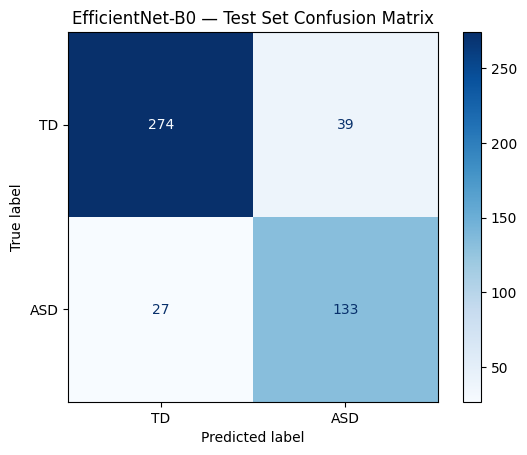

Saved → face_confusion_matrix.png


In [ ]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['TD', 'ASD'])
disp.plot(cmap='Blues')
plt.title('EfficientNet-B0 — Test Set Confusion Matrix')
plt.savefig('/content/drive/MyDrive/face_confusion_matrix.png', dpi=150, bbox_inches='tight') # TODO: update to relative path
plt.show()
print("Saved → face_confusion_matrix.png")

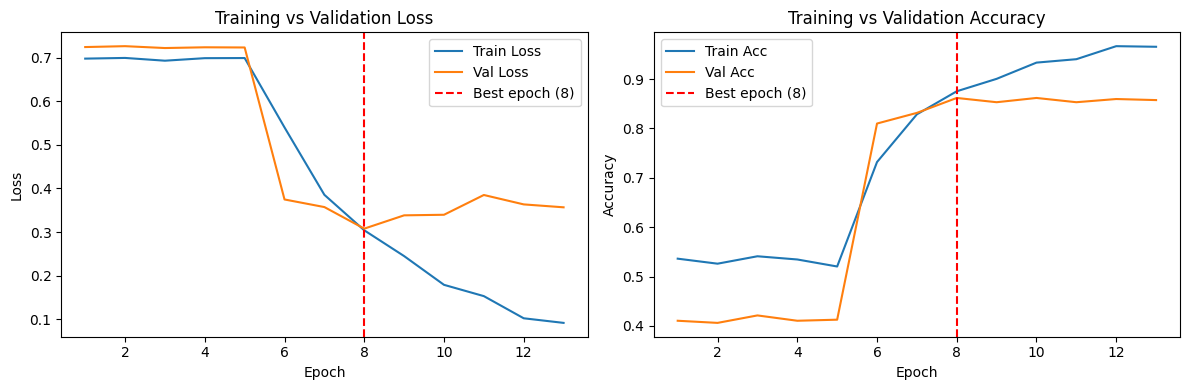

Saved → face_training_curves.png


In [80]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax1.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
ax1.plot(history_df['epoch'], history_df['val_loss'],   label='Val Loss')
ax1.axvline(x=8, color='red', linestyle='--', label='Best epoch (8)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()


# Accuracy curves
ax2.plot(history_df['epoch'], history_df['train_acc'], label='Train Acc')
ax2.plot(history_df['epoch'], history_df['val_acc'],   label='Val Acc')
ax2.axvline(x=8, color='red', linestyle='--', label='Best epoch (8)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/face_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → face_training_curves.png")

## Results Summary

| Metric | Value |
|---|---|
| Test Accuracy | 86.0% |
| ASD Recall | 0.83 |
| ASD Precision | 0.77 |
| ASD F1 | 0.80 |
| TD Recall | 0.88 |
| False Negatives | 27 / 160 ASD cases missed |

The face-only model correctly identifies 83% of ASD children from a facial 
photograph. This establishes the unimodal baseline the fusion model must beat.